Libraries loaded successfully
Test set       : (384, 21)
High-DSR cases : 60  (DSR >= 0.4)
Employment dist: {9.0: 25, 1.0: 15, 2.0: 13, 6.0: 3, 3.0: 2, 5.0: 1, 8.0: 1}
=== Full Heterogeneity Table (All Policies x Subgroups) ===
            Policy   Subgroup  N  Mean DSR reduction  CI lower (95%)  CI upper (95%) Significant
  A-20 (Debt -20%)   Employed 15              0.0127         -0.0200          0.0483          No
  A-20 (Debt -20%) Unemployed 13              0.0313          0.0048          0.0629         Yes
  A-20 (Debt -20%)   Inactive  2              0.1116             NaN             NaN         N/A
  A-40 (Debt -40%)   Employed 15              0.0719          0.0294          0.1254         Yes
  A-40 (Debt -40%) Unemployed 13              0.0663          0.0275          0.1126         Yes
  A-40 (Debt -40%)   Inactive  2              0.2260             NaN             NaN         N/A
  A-60 (Debt -60%)   Employed 15              0.0805          0.0392          0.1347         

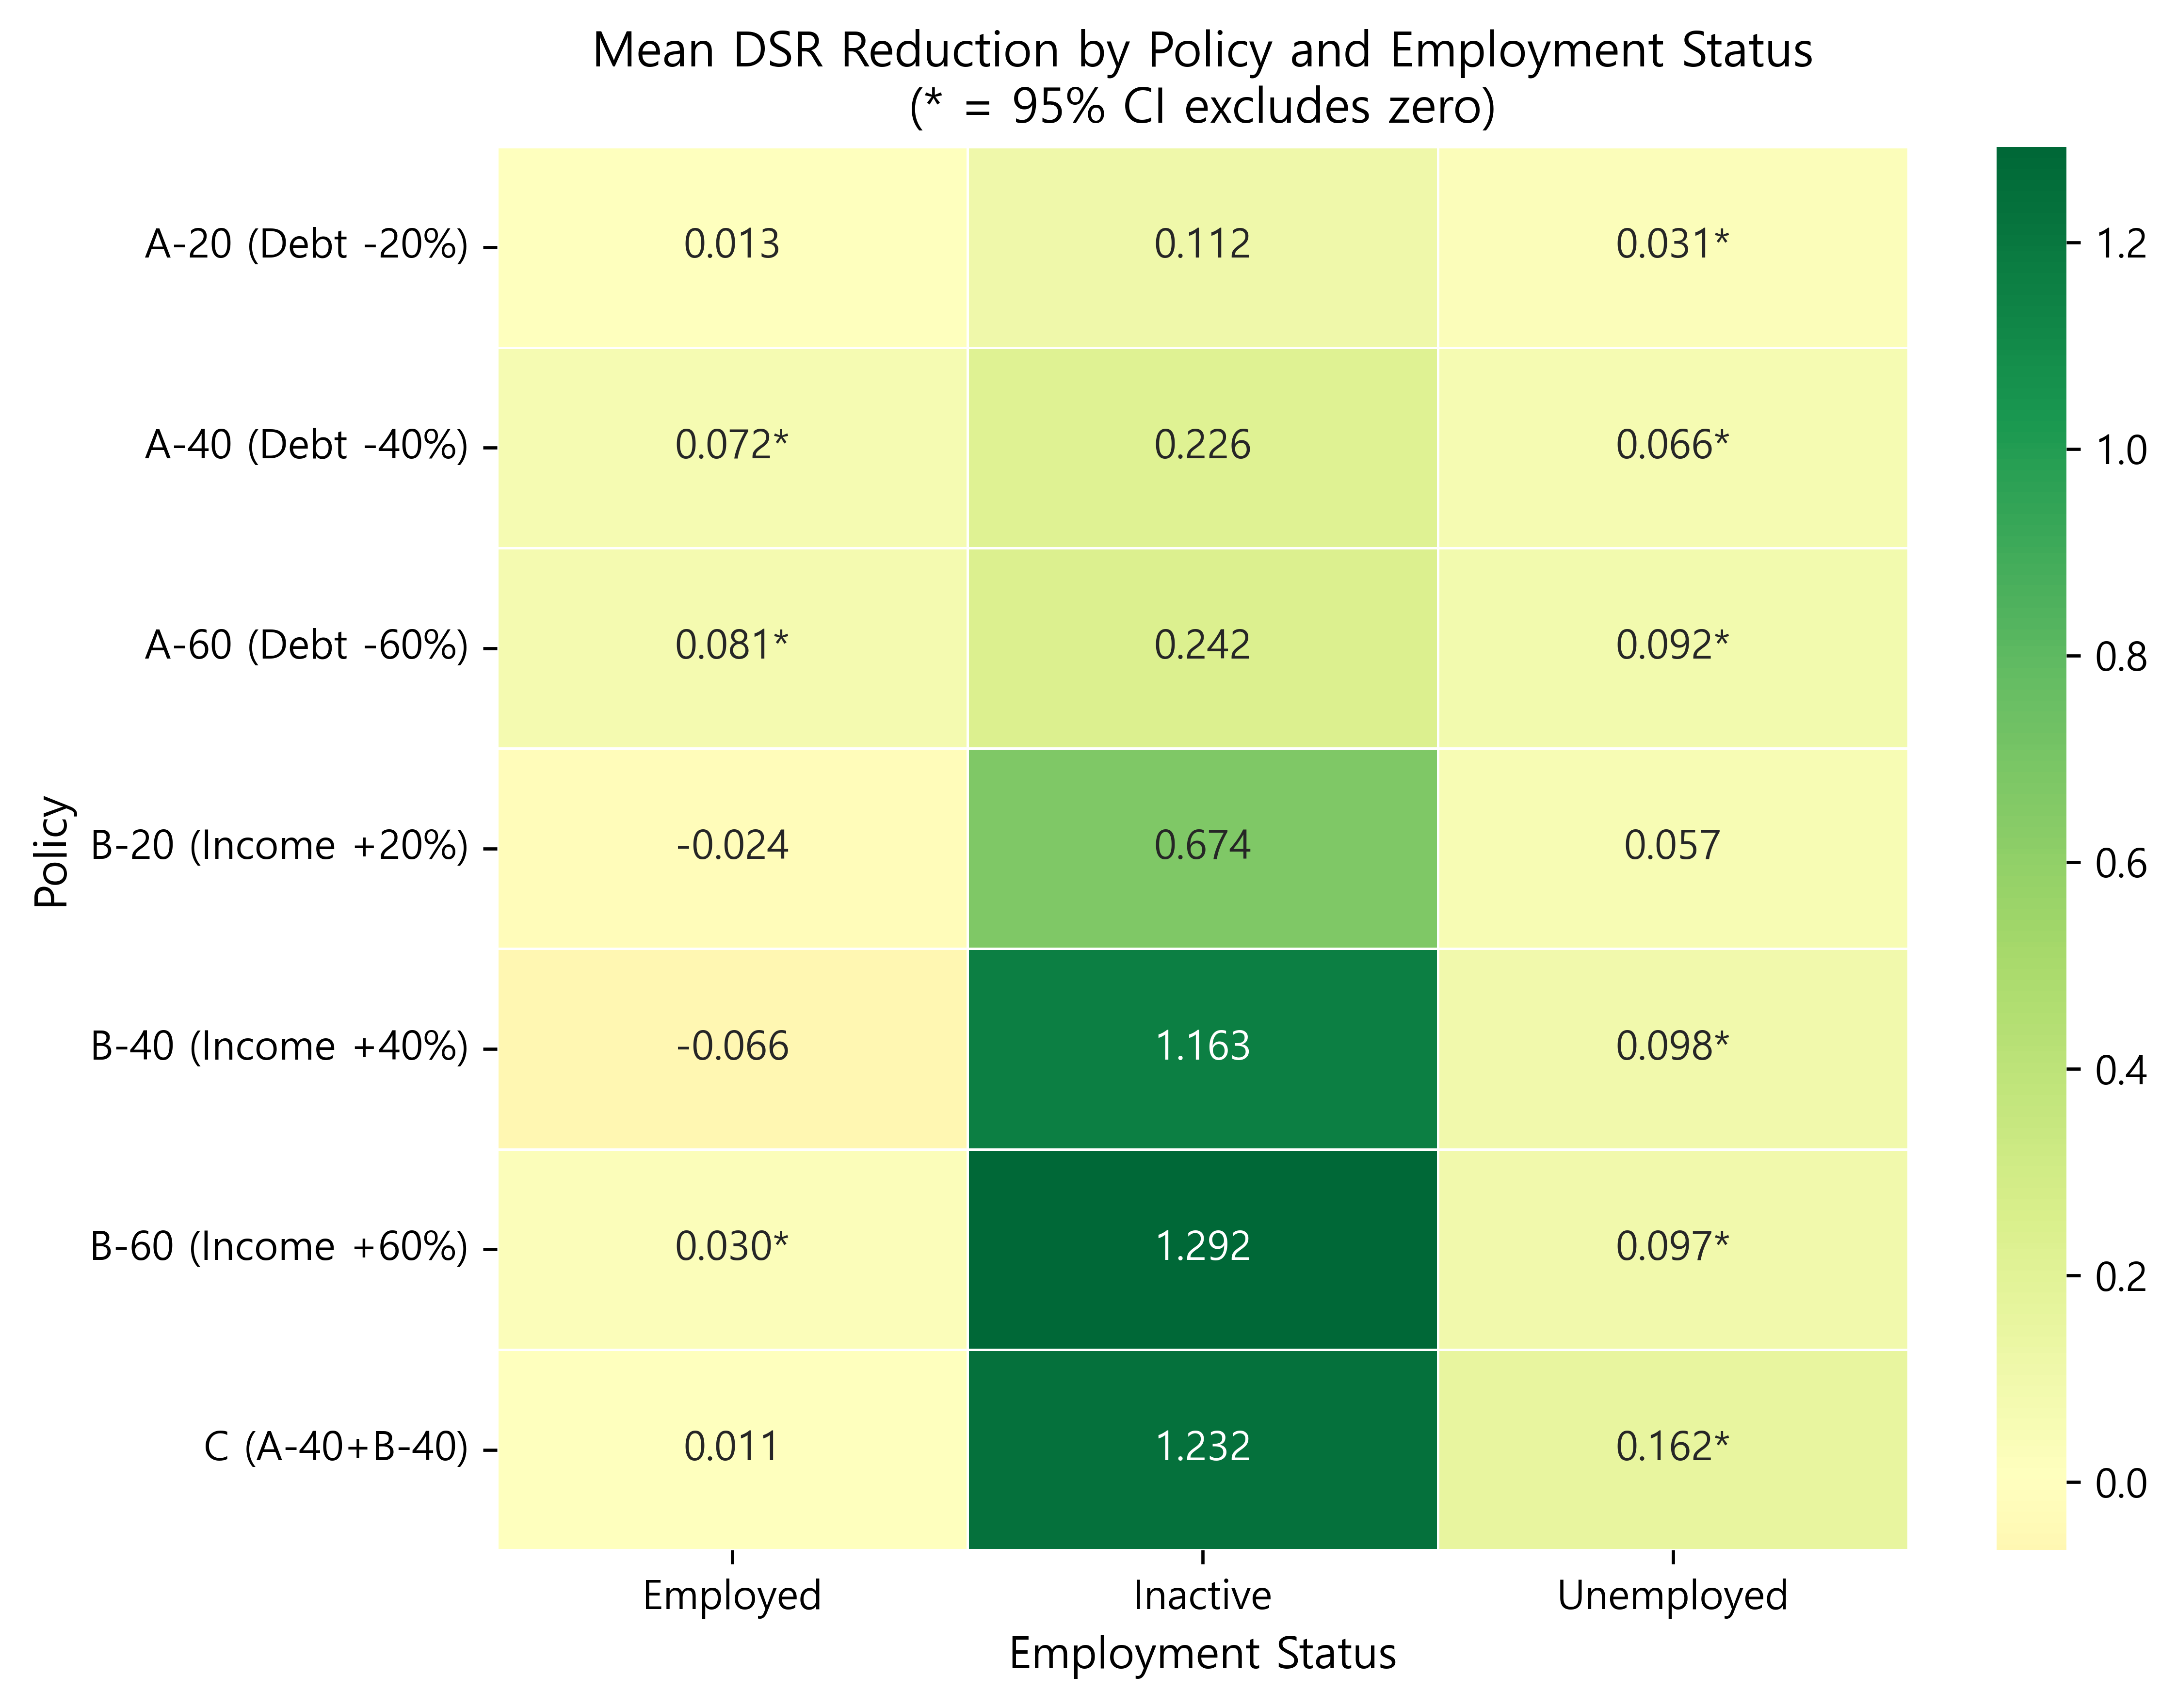

Saved -> outputs/32_heterogeneity_heatmap_reg.png


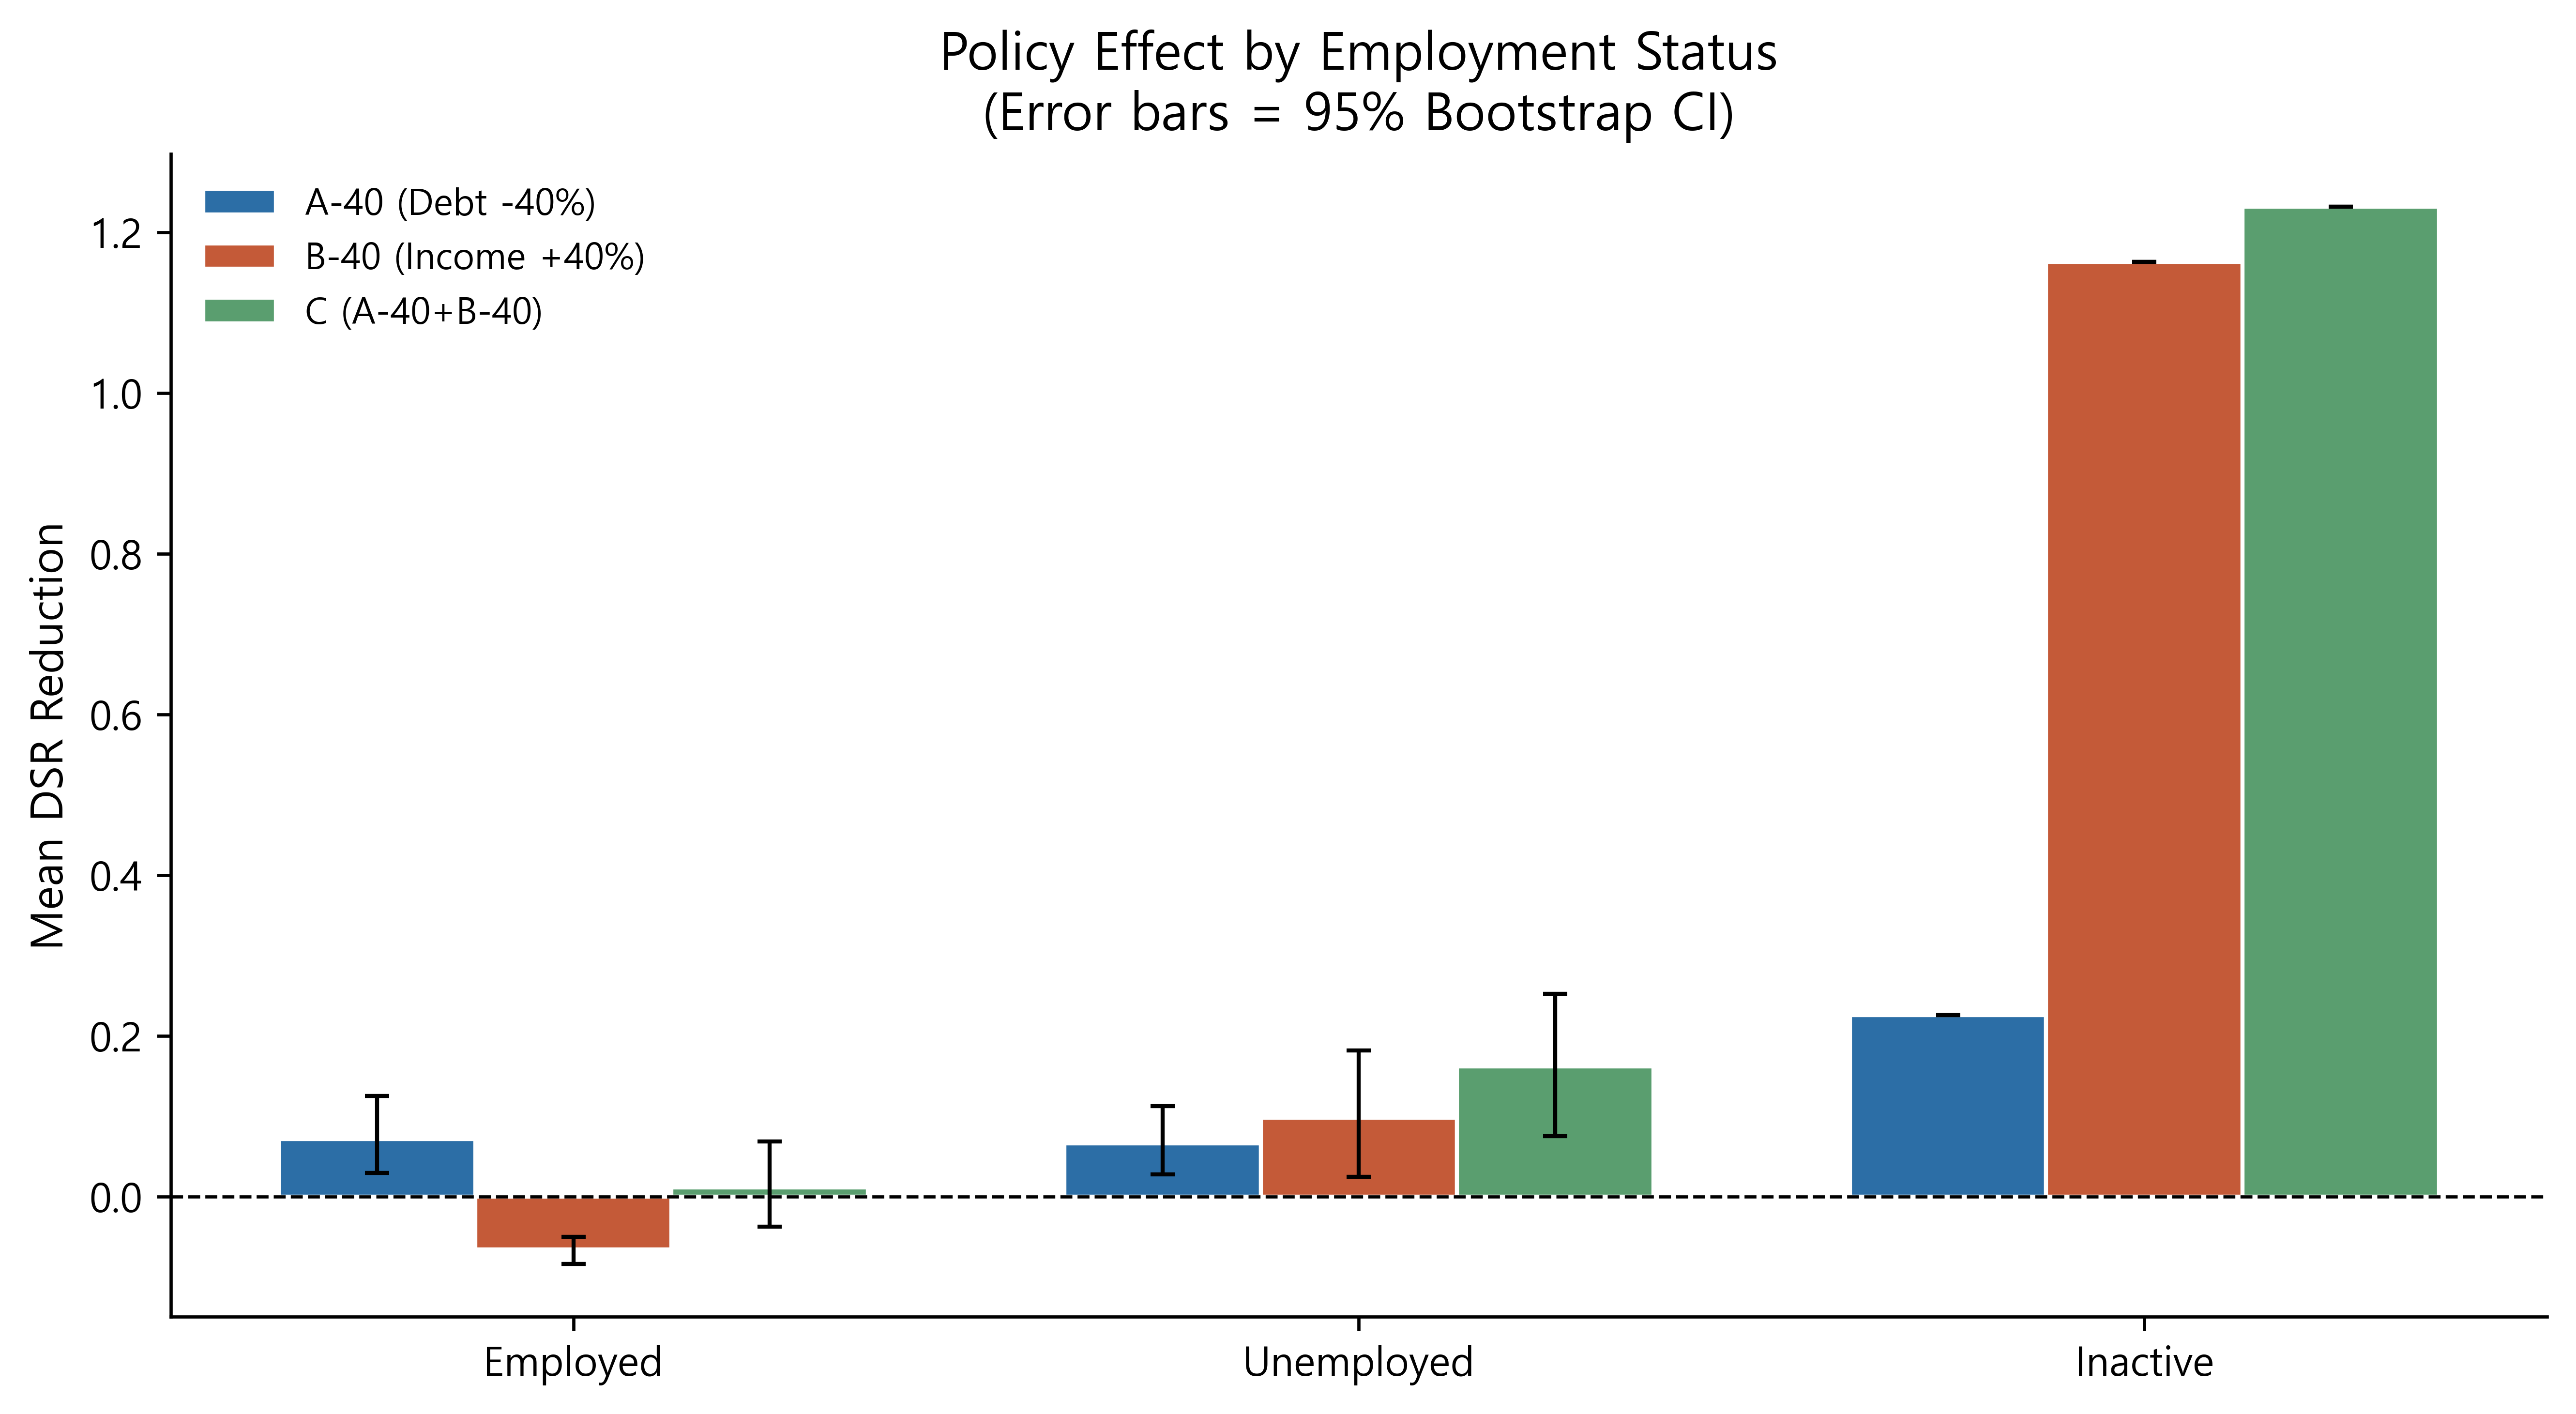

Saved -> outputs/33_heterogeneity_grouped_bar_reg.png


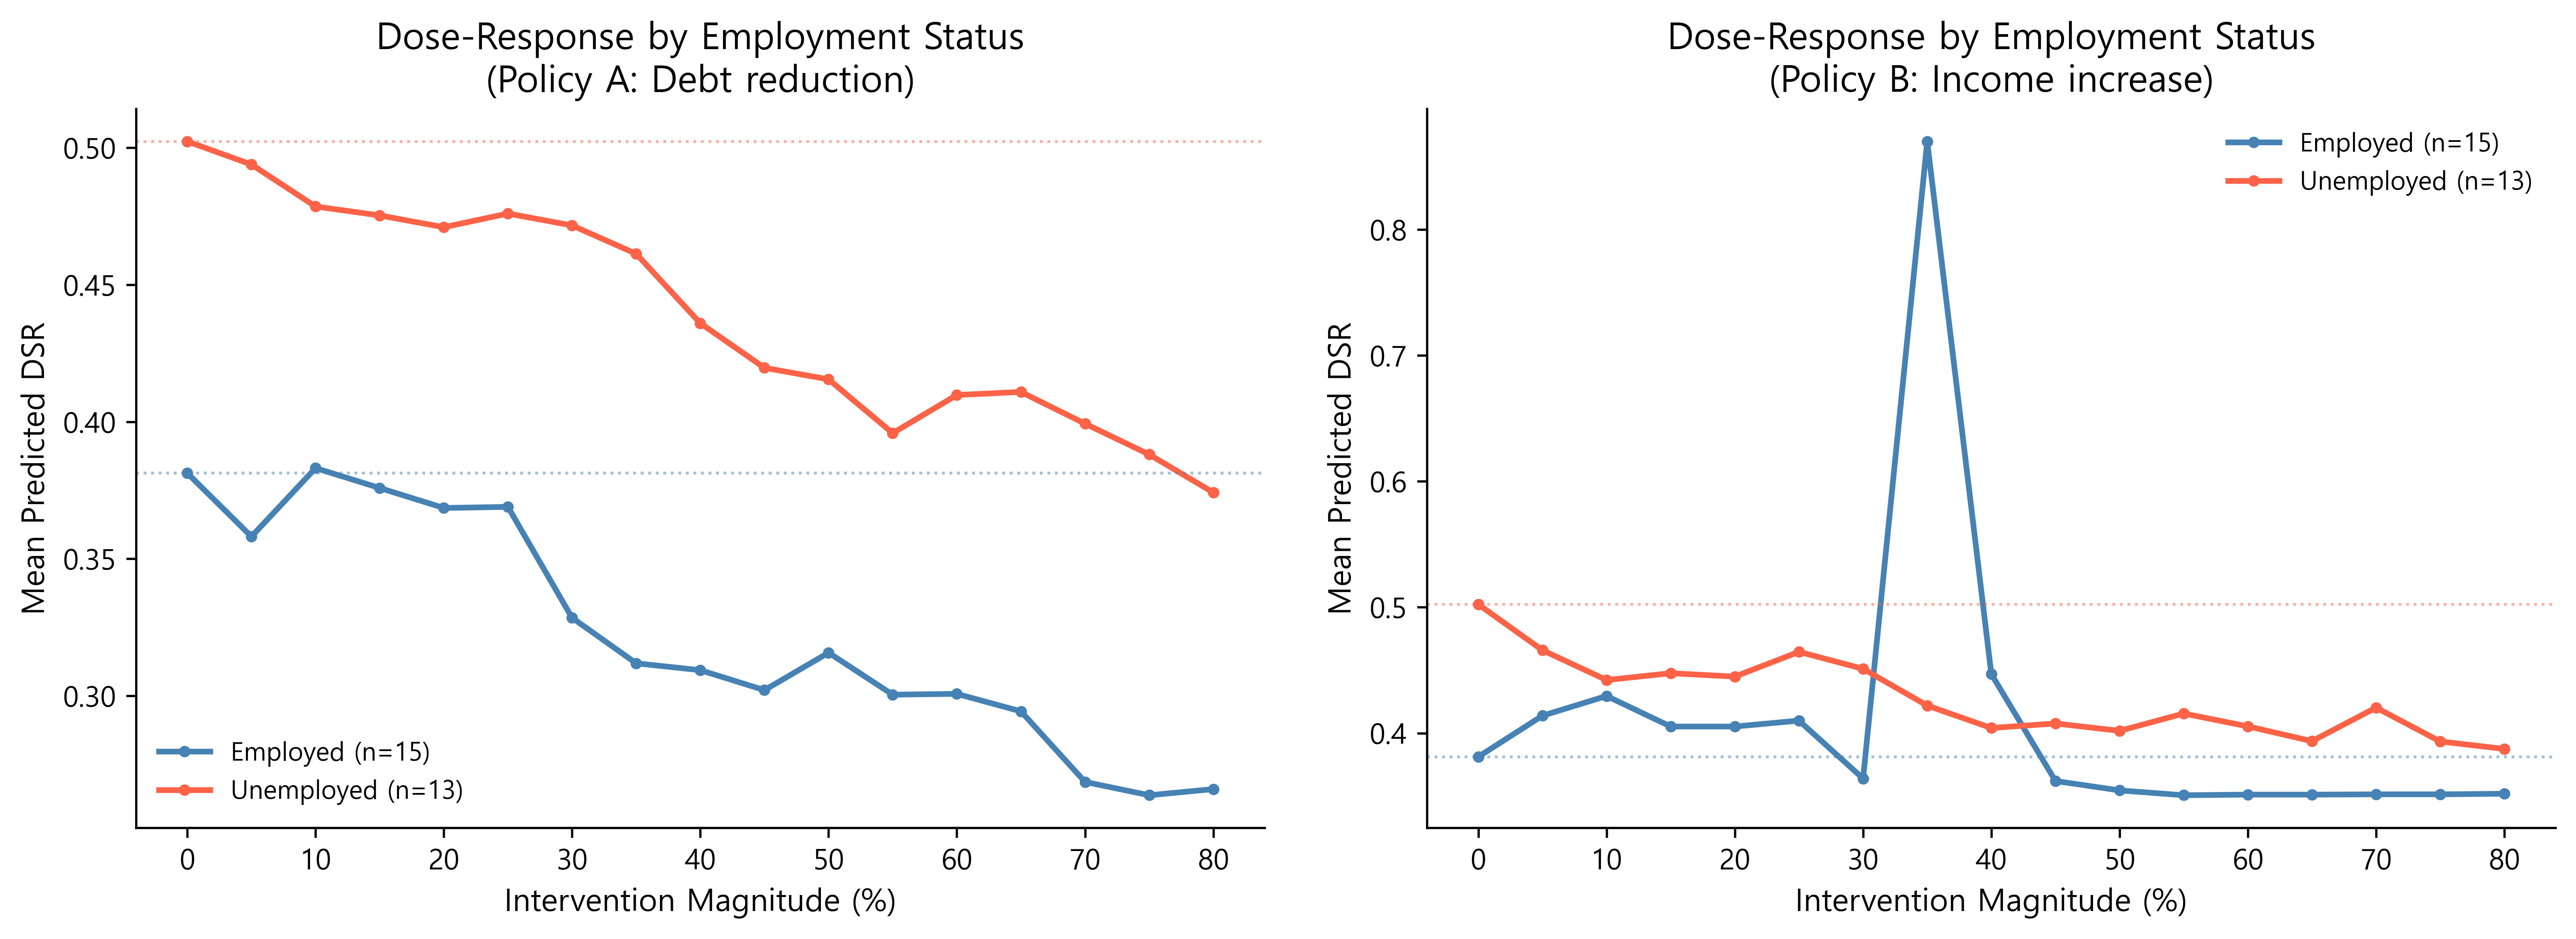

Saved -> outputs/34_dose_response_subgroup_reg.png

=== Crisis Proxy Rate by Policy x Subgroup ===
            Policy   Subgroup  N  Baseline crisis rate  Post-policy rate  Rate reduction
  A-20 (Debt -20%)   Employed 15                0.5333            0.5333          0.0000
  A-20 (Debt -20%) Unemployed 13                0.4615            0.3846          0.0769
  A-20 (Debt -20%)   Inactive  2                1.0000            1.0000          0.0000
  A-40 (Debt -40%)   Employed 15                0.5333            0.4000          0.1333
  A-40 (Debt -40%) Unemployed 13                0.4615            0.3077          0.1538
  A-40 (Debt -40%)   Inactive  2                1.0000            1.0000          0.0000
  A-60 (Debt -60%)   Employed 15                0.5333            0.2667          0.2667
  A-60 (Debt -60%) Unemployed 13                0.4615            0.3846          0.0769
  A-60 (Debt -60%)   Inactive  2                1.0000            1.0000          0.0000
B-20 (Incom

In [3]:
# ═══════════════════════════════════════════════════════════════
# Notebook  : 09_heterogeneity_extended_regression
# Project   : XAI-Driven DSR Prediction Framework for Youth Debt Crisis
# Purpose   : Extended heterogeneity analysis by employment status
#             Policy A, B, C effects separately for each subgroup
#             with 95% bootstrap CI; dose-response by subgroup
# Data      : X_test_reg.csv, y_test_reg.csv, model_lgbm_reg.pkl
# Author    :
# ═══════════════════════════════════════════════════════════════

# ─────────────────────────────────────────────
# Cell 1 | Import libraries
# ─────────────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
import warnings
import joblib

warnings.filterwarnings('ignore')
matplotlib.rcParams['font.family'] = 'Malgun Gothic'
matplotlib.rcParams['axes.unicode_minus'] = False
matplotlib.rcParams['figure.dpi'] = 600
matplotlib.rcParams['savefig.dpi'] = 600
matplotlib.rcParams['font.size'] = 11
matplotlib.rcParams['axes.titlesize'] = 13
matplotlib.rcParams['axes.labelsize'] = 11
matplotlib.rcParams['xtick.labelsize'] = 10
matplotlib.rcParams['ytick.labelsize'] = 10
matplotlib.rcParams['lines.linewidth'] = 1.5
matplotlib.rcParams['axes.linewidth'] = 0.8

SAVE_KW  = dict(dpi=600, bbox_inches='tight', format='png')
N_BOOT   = 1000
DSR_THR  = 0.4
EMP_LABELS = {1: 'Employed', 2: 'Unemployed', 3: 'Inactive'}

print("Libraries loaded successfully")


# ─────────────────────────────────────────────
# Cell 2 | Load model & data
# ─────────────────────────────────────────────
lgbm   = joblib.load('../outputs/model_lgbm_reg.pkl')
X_test = pd.read_csv('../data/X_test_reg.csv')
y_test = pd.read_csv('../data/y_test_reg.csv').squeeze()

X_test_r = X_test.reset_index(drop=True)
y_test_r = y_test.reset_index(drop=True)

# High-DSR cases only
crisis_mask = y_test_r >= DSR_THR
X_crisis    = X_test_r[crisis_mask].reset_index(drop=True)
y_crisis    = y_test_r[crisis_mask].reset_index(drop=True)
pred_base   = lgbm.predict(X_crisis.values)

print(f"Test set       : {X_test_r.shape}")
print(f"High-DSR cases : {X_crisis.shape[0]}  (DSR >= {DSR_THR})")
print(f"Employment dist: {X_crisis['employment_status'].value_counts().to_dict()}")


# ─────────────────────────────────────────────
# Cell 3 | Define policies & simulation helper
# ─────────────────────────────────────────────
POLICIES = {
    'A-20 (Debt -20%)'  : {'debt_financial'  : -0.20},
    'A-40 (Debt -40%)'  : {'debt_financial'  : -0.40},
    'A-60 (Debt -60%)'  : {'debt_financial'  : -0.60},
    'B-20 (Income +20%)': {'h19_pers_income2': +0.20},
    'B-40 (Income +40%)': {'h19_pers_income2': +0.40},
    'B-60 (Income +60%)': {'h19_pers_income2': +0.60},
    'C (A-40+B-40)'     : {'debt_financial'  : -0.40,
                            'h19_pers_income2': +0.40},
}

def simulate(X_base, changes):
    """Apply policy changes and return predicted DSR array."""
    X_sim = X_base.copy()
    for feat, delta in changes.items():
        if feat not in X_sim.columns:
            continue
        if delta < 0:
            X_sim[feat] = (X_sim[feat] * (1 + delta)).clip(lower=0)
        else:
            col_mean    = X_crisis[feat].mean()   # mean of full crisis group
            X_sim[feat] = X_sim[feat] + col_mean * delta
    return lgbm.predict(X_sim.values)

def boot_ci(values, n_boot=N_BOOT, seed=42):
    """Bootstrap 95% CI for the mean of values."""
    rng  = np.random.default_rng(seed)
    n    = len(values)
    if n < 5:
        return np.nan, np.nan
    boot = np.array([values[rng.integers(0, n, n)].mean()
                     for _ in range(n_boot)])
    return np.percentile(boot, 2.5), np.percentile(boot, 97.5)


# ─────────────────────────────────────────────
# Cell 4 | All policies x all subgroups
# DSR reduction with 95% CI per cell
# ─────────────────────────────────────────────
rows = []

for policy_name, changes in POLICIES.items():
    sim_all = simulate(X_crisis, changes)
    red_all = pred_base - sim_all

    for emp_val, emp_label in EMP_LABELS.items():
        mask  = (X_crisis['employment_status'] == emp_val).values
        n_sub = mask.sum()
        if n_sub == 0:
            continue

        sub_red = red_all[mask]
        point   = sub_red.mean()
        lo, hi  = boot_ci(sub_red)

        rows.append({
            'Policy'            : policy_name,
            'Subgroup'          : emp_label,
            'N'                 : int(n_sub),
            'Mean DSR reduction': round(point, 4),
            'CI lower (95%)'    : round(lo, 4) if not np.isnan(lo) else np.nan,
            'CI upper (95%)'    : round(hi, 4) if not np.isnan(hi) else np.nan,
            'Significant'       : ('Yes' if (not np.isnan(lo) and lo > 0)
                                   else ('N/A' if np.isnan(lo) else 'No')),
        })

het_df = pd.DataFrame(rows)
print("=== Full Heterogeneity Table (All Policies x Subgroups) ===")
print(het_df.to_string(index=False))

het_df.to_csv('../outputs/heterogeneity_full_reg.csv',
              index=False, encoding='utf-8-sig')
print("\nSaved -> outputs/heterogeneity_full_reg.csv")


# ─────────────────────────────────────────────
# Cell 5 | Heatmap: mean DSR reduction by policy x subgroup
# ─────────────────────────────────────────────
import seaborn as sns

pivot = het_df.pivot(index='Policy', columns='Subgroup',
                     values='Mean DSR reduction')

# Significance mask (asterisk annotation)
sig_pivot = het_df.pivot(index='Policy', columns='Subgroup',
                          values='Significant')

annot = pivot.copy().astype(str)
for r in annot.index:
    for c in annot.columns:
        val = pivot.loc[r, c]
        sig = sig_pivot.loc[r, c] if c in sig_pivot.columns else 'N/A'
        star = '*' if sig == 'Yes' else ''
        annot.loc[r, c] = f"{val:.3f}{star}" if not np.isnan(val) else 'N/A'

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(pivot, annot=annot, fmt='', cmap='RdYlGn',
            center=0, linewidths=0.4, linecolor='white',
            annot_kws={'size': 10}, ax=ax)
ax.set_title('Mean DSR Reduction by Policy and Employment Status\n'
             '(* = 95% CI excludes zero)', fontsize=12)
ax.set_xlabel('Employment Status', fontsize=11)
ax.set_ylabel('Policy', fontsize=11)
plt.tight_layout()
plt.savefig('../outputs/32_heterogeneity_heatmap_reg.png', **SAVE_KW)
plt.show()
print("Saved -> outputs/32_heterogeneity_heatmap_reg.png")


# ─────────────────────────────────────────────
# Cell 6 | Grouped bar chart: Policy A vs B vs C by subgroup
# Focus on A-40, B-40, C for clean comparison
# ─────────────────────────────────────────────
focus_policies = ['A-40 (Debt -40%)', 'B-40 (Income +40%)', 'C (A-40+B-40)']
focus_df       = het_df[het_df['Policy'].isin(focus_policies)].copy()
subgroups      = [s for s in ['Employed', 'Unemployed', 'Inactive']
                  if s in focus_df['Subgroup'].unique()]

x      = np.arange(len(subgroups))
width  = 0.25
colors = ['#2c6ea6', '#c45a38', '#5a9e6f']

fig, ax = plt.subplots(figsize=(9, 5))

for i, (pol, color) in enumerate(zip(focus_policies, colors)):
    sub = focus_df[focus_df['Policy'] == pol].set_index('Subgroup')
    vals  = [sub.loc[s, 'Mean DSR reduction'] if s in sub.index else 0
             for s in subgroups]
    los   = [sub.loc[s, 'CI lower (95%)'] if s in sub.index else 0
             for s in subgroups]
    his   = [sub.loc[s, 'CI upper (95%)'] if s in sub.index else 0
             for s in subgroups]
    yerr  = np.array([
        [v - l if not np.isnan(l) else 0 for v, l in zip(vals, los)],
        [h - v if not np.isnan(h) else 0 for v, h in zip(vals, his)]
    ])
    offset = (i - 1) * width
    bars   = ax.bar(x + offset, vals, width=width,
                    color=color, label=pol, edgecolor='white', zorder=2)
    ax.errorbar(x + offset, vals, yerr=yerr, fmt='none',
                color='black', capsize=3, capthick=1.0,
                elinewidth=1.0, zorder=3)

ax.axhline(0, color='black', lw=0.8, linestyle='--')
ax.set_xticks(x)
ax.set_xticklabels(subgroups)
ax.set_ylabel('Mean DSR Reduction')
ax.set_title('Policy Effect by Employment Status\n'
             '(Error bars = 95% Bootstrap CI)')
ax.legend(frameon=False, fontsize=9)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.savefig('../outputs/33_heterogeneity_grouped_bar_reg.png', **SAVE_KW)
plt.show()
print("Saved -> outputs/33_heterogeneity_grouped_bar_reg.png")


# ─────────────────────────────────────────────
# Cell 7 | Dose-response by employment status subgroup
# How does each subgroup respond as intervention magnitude increases?
# ─────────────────────────────────────────────
magnitudes = np.arange(0, 0.85, 0.05)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
sub_colors = {'Employed': 'steelblue',
              'Unemployed': 'tomato',
              'Inactive': 'seagreen'}

for ax, (policy_type, feat, label) in zip(axes, [
    ('Debt reduction',  'debt_financial',   'Policy A'),
    ('Income increase', 'h19_pers_income2', 'Policy B'),
]):
    for emp_val, emp_label in EMP_LABELS.items():
        mask  = (X_crisis['employment_status'] == emp_val).values
        if mask.sum() < 3:
            continue

        dsr_curve = []
        for delta in magnitudes:
            X_sim = X_crisis.copy()
            if policy_type == 'Debt reduction':
                X_sim[feat] = (X_sim[feat] * (1 - delta)).clip(lower=0)
            else:
                col_mean    = X_crisis[feat].mean()
                X_sim[feat] = X_sim[feat] + col_mean * delta
            preds = lgbm.predict(X_sim.values)
            dsr_curve.append(preds[mask].mean())

        ax.plot(magnitudes * 100, dsr_curve,
                color=sub_colors.get(emp_label, 'gray'),
                lw=2, marker='o', markersize=3,
                label=f'{emp_label} (n={mask.sum()})')

    # Baseline per subgroup
    for emp_val, emp_label in EMP_LABELS.items():
        mask = (X_crisis['employment_status'] == emp_val).values
        if mask.sum() < 3:
            continue
        ax.axhline(pred_base[mask].mean(),
                   color=sub_colors.get(emp_label, 'gray'),
                   linestyle=':', lw=1.0, alpha=0.5)

    ax.set_xlabel('Intervention Magnitude (%)')
    ax.set_ylabel('Mean Predicted DSR')
    ax.set_title(f'Dose-Response by Employment Status\n({label}: {policy_type})')
    ax.legend(frameon=False, fontsize=9)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

plt.tight_layout(pad=2.0)
plt.savefig('../outputs/34_dose_response_subgroup_reg.png', **SAVE_KW)
plt.show()
print("Saved -> outputs/34_dose_response_subgroup_reg.png")


# ─────────────────────────────────────────────
# Cell 8 | Crisis proxy rate by policy x subgroup
# Proportion with predicted DSR >= 0.4 after intervention
# ─────────────────────────────────────────────
rate_rows = []

for policy_name, changes in POLICIES.items():
    sim_all = simulate(X_crisis, changes)

    for emp_val, emp_label in EMP_LABELS.items():
        mask  = (X_crisis['employment_status'] == emp_val).values
        n_sub = mask.sum()
        if n_sub == 0:
            continue

        base_rate = (pred_base[mask] >= DSR_THR).mean()
        sim_rate  = (sim_all[mask] >= DSR_THR).mean()
        rate_red  = base_rate - sim_rate

        rate_rows.append({
            'Policy'              : policy_name,
            'Subgroup'            : emp_label,
            'N'                   : int(n_sub),
            'Baseline crisis rate': round(base_rate, 4),
            'Post-policy rate'    : round(sim_rate, 4),
            'Rate reduction'      : round(rate_red, 4),
        })

rate_df = pd.DataFrame(rate_rows)
print("\n=== Crisis Proxy Rate by Policy x Subgroup ===")
print(rate_df.to_string(index=False))

rate_df.to_csv('../outputs/heterogeneity_crisis_rate_reg.csv',
               index=False, encoding='utf-8-sig')
print("\nSaved -> outputs/heterogeneity_crisis_rate_reg.csv")


# ─────────────────────────────────────────────
# Cell 9 | Summary: optimal policy per subgroup
# Which policy gives the largest significant DSR reduction?
# ─────────────────────────────────────────────
print("\n=== Optimal Policy per Subgroup ===")

for emp_label in ['Employed', 'Unemployed']:
    sub = het_df[het_df['Subgroup'] == emp_label].copy()
    sub = sub[sub['Significant'] == 'Yes']
    if len(sub) == 0:
        print(f"  {emp_label:<12}: No statistically significant policy found")
        continue
    best = sub.loc[sub['Mean DSR reduction'].idxmax()]
    print(f"  {emp_label:<12}: Best policy = {best['Policy']}"
          f"  (DSR reduction={best['Mean DSR reduction']:.4f},"
          f"  95% CI [{best['CI lower (95%)']:.4f},"
          f"  {best['CI upper (95%)']:.4f}])")